<a href="https://colab.research.google.com/github/tarannump096-cpu/NLP/blob/main/NewYork_City_Taxi_Fare_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("/content/data.csv", nrows=200000)  # limit rows for faster training
print(df.head())

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2020-01-01 00:28:15   2020-01-01 00:33:03                1   
1         1  2020-01-01 00:35:39   2020-01-01 00:43:04                1   
2         1  2020-01-01 00:47:41   2020-01-01 00:53:52                1   
3         1  2020-01-01 00:55:23   2020-01-01 01:00:14                1   
4         2  2020-01-01 00:01:58   2020-01-01 00:04:16                1   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0            1.2           1                  N           238           239   
1            1.2           1                  N           239           238   
2            0.6           1                  N           238           238   
3            0.8           1                  N           238           151   
4            0.0           1                  N           193           193   

   payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_amount  \


In [3]:
df = df.dropna()

In [4]:
df = df[df['fare_amount'] > 0]

In [5]:
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]

In [7]:
df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['weekday'] = df['pickup_datetime'].dt.weekday

In [25]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(np.radians,
                                 [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [27]:
df = df[(df['fare_amount'] < 200)]

In [30]:
features = ['passenger_count', 'hour', 'day', 'month', 'weekday', 'trip_distance']
X = df[features]
y = df['fare_amount']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [33]:
y_pred = model.predict(X_test)

In [34]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 4.671885870334322


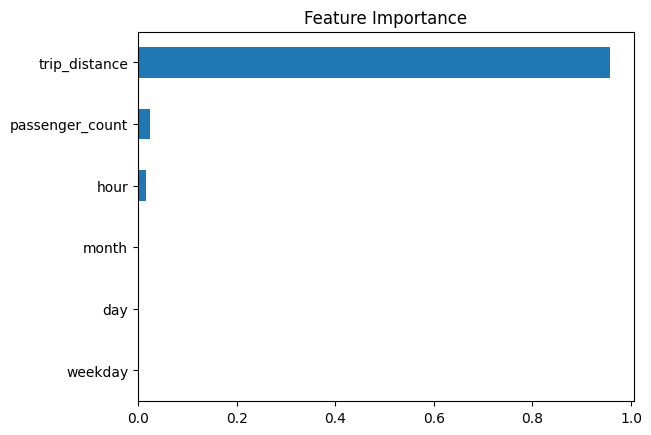

In [35]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()